# Word2Vec in Pytorch
### 程式來自[Word2Vec in Pytorch - Continuous Bag of Words and Skipgrams](https://srijithr.gitlab.io/post/word2vec/)

## CBOW

<img src='nlp_data/Cbow.png' width=500 align='left'>

## 載入相關套件

In [1]:
import urllib.request
from typing import List

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from torch.nn import functional as F
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer

## 參數設定

In [2]:
torch.manual_seed(1)  # 固定亂數種子
CONTEXT_SIZE = 3  # 上下文個數
EMBEDDING_DIM = 10  # 嵌入層輸出維度

## 文字處理函數

In [3]:
# 以值(value)找鍵值(key)
def get_key(word_id: int) -> str:
    for key, val in word_to_ix.items():
        if val == word_id:
            return key
    return ''


# 分詞及前置處理
def read_data(file_path: str, remove_stopwords: bool = False) -> List[str]:
    tokenizer = RegexpTokenizer(r'\w+')
    if file_path.lower().startswith('http'):
        data = urllib.request.urlopen(file_path)
        data = data.read().decode('utf8')
    else:
        data = open(file_path, encoding='utf8').read()
    tokenized_data = word_tokenize(data)
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
    else:
        stop_words = set([])
    stop_words.update(['.', ',', ':', ';', '(', ')', '#', '--', '...', '"'])
    cleaned_words = [i for i in tokenized_data if i not in stop_words]
    return cleaned_words

## 測試本文(Text)

In [4]:
test_sentence = read_data('nlp_data/word2vec_test.txt')

# 或讀取其他檔案
# test_sentence = read_data('https://www.gutenberg.org/files/57884/57884-0.txt')
# test_sentence = read_data('nlp_data/57884-0.txt')

## N-grams 處理

In [5]:
ngrams: list[tuple[list[str], str]] = []
for i in range(len(test_sentence) - CONTEXT_SIZE):
    tup = [test_sentence[j] for j in np.arange(i, i + CONTEXT_SIZE)]
    ngrams.append((tup, test_sentence[i + CONTEXT_SIZE]))

print(ngrams[0], ngrams[1])

(['Empathy', 'for', 'the'], 'poor') (['for', 'the', 'poor'], 'may')


## 詞彙表設定

In [6]:
# 取得詞彙表(vocabulary)
vocab = set(test_sentence)
print("單字個數：", len(vocab))

# 建立字典，以單字取得代碼
word_to_ix = {word: i for i, word in enumerate(vocab)}

單字個數： 192


## CBOW 模型

In [7]:
class CBOWModeler(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, context_size: int) -> None:
        super(CBOWModeler, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(context_size * embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        # embeds -> linear -> relu -> linear -> log_softmax
        embeds = self.embeddings(inputs).view((1, -1))
        out1 = F.relu(self.linear1(embeds))
        out2 = self.linear2(out1)
        log_probs = F.log_softmax(out2, dim=1)
        return log_probs

    def predict(self, input: List[str]) -> None:
        # 以上下文預測
        context_idxs = torch.LongTensor([word_to_ix[w] for w in input])
        res = self.forward(context_idxs)
        res_arg = torch.argmax(res)
        res_val, res_ind = res.sort(descending=True)
        res_val = res_val[0][:3]  # 前3個預測值
        res_ind = res_ind[0][:3]  # 前3個預測索引值
        for arg in zip(res_val, res_ind):
            print([(key, val, arg[0]) for key, val in word_to_ix.items() if val == arg[1]])

## 訓練

In [8]:
losses: list[float] = []
loss_function = nn.NLLLoss()
model = CBOWModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE)
optimizer = optim.SGD(model.parameters(), lr=0.001)

for epoch in range(400):
    total_loss = 0.0
    for context, target in ngrams:
        # 以單字取得代碼
        context_idxs = torch.LongTensor([word_to_ix[w] for w in context])

        # 梯度下降
        model.zero_grad()
        log_probs: torch.Tensor = model(context_idxs)
        loss: torch.Tensor = loss_function(log_probs, torch.LongTensor([word_to_ix[target]]))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)

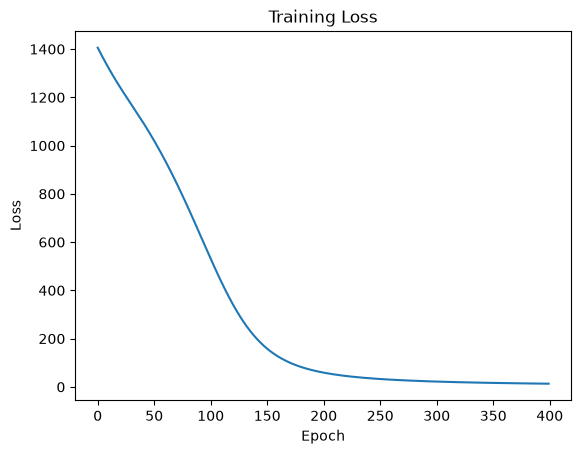

In [9]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

## 預測

In [10]:
model.predict(['of', 'all', 'human'])

[('afflictions', 45, tensor(-0.0351, grad_fn=<UnbindBackward0>))]
[('boy', 176, tensor(-4.5903, grad_fn=<UnbindBackward0>))]
[('health', 59, tensor(-4.8746, grad_fn=<UnbindBackward0>))]


## Skip-gram 

<img src='nlp_data/Skip-gram.png' width=500 align='left'>

## N-grams 處理

In [11]:
ngrams: list[tuple[str, list[str]]] = []
for i in range(len(test_sentence) - CONTEXT_SIZE):
    tup = [test_sentence[j] for j in np.arange(i + 1, i + CONTEXT_SIZE + 1)]
    ngrams.append((test_sentence[i], tup))
print(ngrams[0], ngrams[1])

('Empathy', ['for', 'the', 'poor']) ('for', ['the', 'poor', 'may'])


## Skip-Gram 模型

In [12]:
class SkipgramModeler(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int, context_size: int) -> None:
        super(SkipgramModeler, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(embedding_dim, 128)
        self.linear2 = nn.Linear(128, context_size * vocab_size)
        # self.parameters['context_size'] = context_size

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        # embeds -> linear -> relu -> linear -> log_softmax
        embeds = self.embeddings(inputs).view((1, -1))
        out1 = F.relu(self.linear1(embeds))
        out2 = self.linear2(out1)
        log_probs = F.log_softmax(out2, dim=1).view(CONTEXT_SIZE, -1)
        return log_probs

    def predict(self, input: str) -> None:
        context_idxs = torch.LongTensor([word_to_ix[input]])
        res = self.forward(context_idxs)
        res_arg = torch.argmax(res)
        res_val, res_ind = res.sort(descending=True)
        indices = [res_ind[i][0] for i in np.arange(0, 3)]
        for arg in indices:
            print([(key, val) for key, val in word_to_ix.items() if val == arg])

## 訓練

In [13]:
losses: list[float] = []
loss_function = nn.NLLLoss()
model = SkipgramModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE)
optimizer = optim.SGD(model.parameters(), lr=0.001)

# Freeze embedding layer
# model.freeze_layer('embeddings')

for epoch in range(550):
    total_loss = 0.0
    # model.predict('psychologically')

    for context, target in ngrams:
        context_idxs = torch.LongTensor([word_to_ix[context]])
        model.zero_grad()
        log_probs: torch.Tensor = model(context_idxs)
        target_list = torch.LongTensor([word_to_ix[w] for w in target])
        loss: torch.Tensor = loss_function(log_probs, target_list)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)

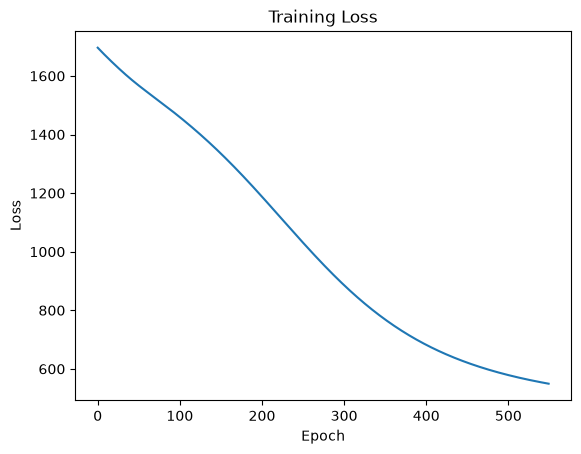

In [14]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

## 預測

In [15]:
model.predict('psychologically')

[('and', 109)]
[('physically', 129)]
[('incapacitating', 177)]
